# - To load dataset

In [136]:
import pandas as pd

data = pd.read_csv("/kaggle/input/password-generator/common_passwords.csv")

display(data.head())
display(data.tail())
print("Shape:", data.shape)
display(data.describe(include="all"))


,password,length,num_chars,num_digits,num_upper,num_lower,num_special,num_vowels,num_syllables
0,123456,6,0,6,0,0,0,0,1
1,password,8,8,0,0,8,0,2,2
2,12345678,8,0,8,0,0,0,0,1
3,qwerty,6,6,0,0,6,0,1,3
4,123456789,9,0,9,0,0,0,0,1


,password,length,num_chars,num_digits,num_upper,num_lower,num_special,num_vowels,num_syllables
9995,caca,4,4,0,0,4,0,2,2
9996,c2h5oh,6,4,2,0,4,0,1,1
9997,bubbles1,8,7,1,0,7,0,2,2
9998,brook,5,5,0,0,5,0,2,1
9999,brady,5,5,0,0,5,0,1,1


Shape: (10000, 9)


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,password,length,num_chars,num_digits,num_upper,num_lower,num_special,num_vowels,num_syllables
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,9998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,abcdef,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,6.651300,5.030300,1.617600,0.025300,5.005000,0.003400,1.805900,1.606600
std,NaN,1.370947,2.804098,2.971911,0.322909,2.809727,0.119958,1.242409,0.681383
min,NaN,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,6.000000,4.000000,0.000000,0.000000,4.000000,0.000000,1.000000,1.000000
50%,NaN,7.000000,6.000000,0.000000,0.000000,6.000000,0.000000,2.000000,2.000000
75%,NaN,8.000000,7.000000,1.000000,0.000000,7.000000,0.000000,3.000000,2.000000


# - Turn the passwords into numerical forms

In [137]:
def extract_features(password):
    return {
        "length": len(password),
        "digits": sum(c.isdigit() for c in password),
        "uppercase": sum(c.isupper() for c in password),
        "special": sum(not c.isalnum() for c in password)
    }

features = data["password"].apply(extract_features)
df_features = pd.DataFrame(list(features))


# - Regression + Classification 

In [138]:
df = pd.concat([data["password"], df_features], axis=1)

df["strength_score"] = (
    df["length"] +
    df["digits"] * 2 +
    df["uppercase"] * 2 +
    df["special"] * 3
)

df["strength_label"] = (df["strength_score"] >= 12).astype(int)


# To Train Models

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = df[["length", "digits", "uppercase", "special"]]
y_class = df["strength_label"]
y_reg = df["strength_score"]

X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

clf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

reg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

clf_model.fit(X_train, y_class_train)
reg_model.fit(X_train, y_reg_train)


Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

# - Evaluation

In [140]:
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

class_preds = clf_model.predict(X_test)
reg_preds = reg_model.predict(X_test)

print("Accuracy:", accuracy_score(y_class_test, class_preds))
print("MSE:", mean_squared_error(y_reg_test, reg_preds))
print("R2 Score:", r2_score(y_reg_test, reg_preds))


Accuracy: 1.0
MSE: 1.2680146246218018e-27
R2 Score: 1.0


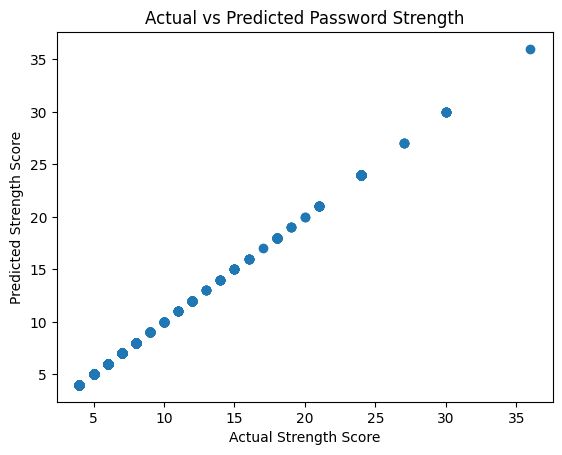

In [141]:
import matplotlib.pyplot as plt

plt.scatter(y_reg_test, reg_preds)
plt.xlabel("Actual Strength Score")
plt.ylabel("Predicted Strength Score")
plt.title("Actual vs Predicted Password Strength")
plt.show()


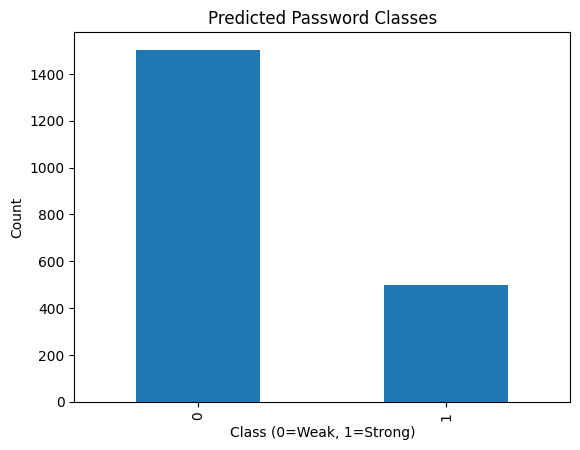

In [142]:
pd.Series(class_preds).value_counts().plot(kind="bar")
plt.title("Predicted Password Classes")
plt.xlabel("Class (0=Weak, 1=Strong)")
plt.ylabel("Count")
plt.show()


# - Password Generator Function

In [143]:
import random
import string

def generate_password(length=12):
    chars = string.ascii_letters + string.digits + "!@#$%^&*"
    return "".join(random.choice(chars) for _ in range(length))


# - Gradio Interface ( Password Checker )

In [144]:
import gradio as gr
import pandas as pd
import random
import string

css_design = """
body { background-color: #0b0b0b; font-family: Arial, sans-serif; }
.gradio-container { background-color: #0b0b0b; color: white; }
label { color: #f5c542 !important; font-weight: bold; font-size: 16px; }
input, textarea {
    background-color: #1a1a1a !important;
    color: white !important;
    border: 2px solid #f5c542 !important;
    border-radius: 8px;
    padding: 8px;
}
button {
    background-color: #f5c542 !important;
    color: black !important;
    font-weight: bold;
    border-radius: 8px;
    padding: 12px 20px;
    font-size: 16px;
    margin-top: 5px;
}
.card {
    background-color: #1a1a1a;
    border: 2px solid #f5c542;
    border-radius: 12px;
    padding: 20px;
    box-shadow: 0px 0px 15px #f5c54255;
}
.progress-bar {
    width: 100%;
    background-color: #333;
    border-radius: 10px;
    overflow: hidden;
    margin-top: 10px;
}
.progress {
    height: 20px;
    border-radius: 10px;
}
"""

# Dummy placeholders
def extract_features(password):
    return {"length": len(password)}

class DummyModel:
    def predict(self, X):
        return [1 if X.iloc[0]["length"] > 8 else 0]

# Random password generator like qwertyuiop
def generate_password(length=12):
    if length < 8:
        length = 8  # will just maintain how long random pass will be and will not get over 8

    lower = string.ascii_lowercase
    upper = string.ascii_uppercase
    digits = string.digits
    symbols = "!@#$%^&*()-_=+[]{}<>?/"

    # the password generator will make literally everything, every symbol,letters and so on
    password = [
        random.choice(lower),
        random.choice(upper),
        random.choice(digits),
        random.choice(symbols)
    ]

    # the pass will be just randomized/shufflled
    all_chars = lower + upper + digits + symbols
    password += random.choices(all_chars, k=length - 4)

    random.shuffle(password)
    return "".join(password)

clf_model = DummyModel()
reg_model = DummyModel()

def check_password(password):
    feats = extract_features(password)
    X_input = pd.DataFrame([feats])
    
    strength_class = clf_model.predict(X_input)[0]
    strength_score = min(max(reg_model.predict(X_input)[0], 0), 1) * 100  # scale 0-100
    # labeled as a game. But this is for password generating like when your low level in a game and you keep losing it'll say to improve your levels and equipments
    label = "Unbreachable!" if strength_class == 1 else "Needs Improvement..."
    suggestion = generate_password(length=12)  # randomized strong password
    
    # Color-coded for how strong your pass is?
    if strength_score < 40:
        color = "#ff4c4c"  # red
    elif strength_score < 70:
        color = "#f5c542"  # yellow
    else:
        color = "#4cff4c"  # green
    
    progress_html = f'<div class="progress-bar"><div class="progress" style="width:{strength_score}%; background-color:{color};"></div></div>'
    
    return label, round(strength_score, 2), progress_html, suggestion

with gr.Blocks(css=css_design, title="Databreak") as interface:
    
    gr.Markdown("## Databreak\nThis tool checks how strong your password really is and whether it can stand up against potential data breaches.", 
                elem_id="description")

    # Horizontal layout to design remember this 
    with gr.Row():
        with gr.Column(scale=2):
            # Card design 1
            with gr.Group(elem_classes="card"):
                password_input = gr.Textbox(label="Enter Password", type="password", placeholder="Type your password here...")
                check_button = gr.Button("Check Password")
        
        with gr.Column(scale=3):
            # Card design 2
            with gr.Group(elem_classes="card"):
                strength_label = gr.Textbox(label="Predicted Strength", interactive=False)
                strength_score = gr.Number(label="Strength Score", interactive=False)
                strength_bar = gr.HTML(label="Strength Meter")
                suggestion_box = gr.Textbox(label="Suggested Strong Password", interactive=False)
    
    check_button.click(
        fn=check_password,
        inputs=password_input,
        outputs=[strength_label, strength_score, strength_bar, suggestion_box]
    )

interface.launch()


* Running on local URL:  http://127.0.0.1:7873
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://4cf20e29b62938f27d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
